In [ ]:
import numpy as np
import pandas as pd
import os

folder = os.getcwd()
for dirname, _, filenames in os.walk(folder):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [20]:
df = pd.read_csv('mnist_train.csv')

In [21]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
import matplotlib.pyplot as plt

In [23]:
df.sample()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
41648,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


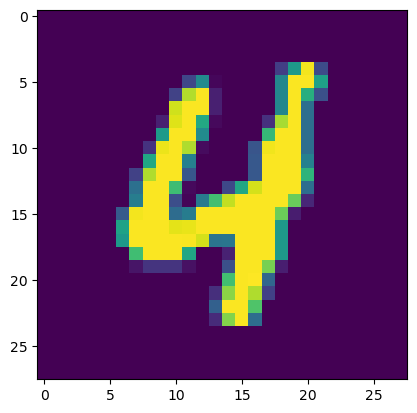

In [24]:
plt.imshow(df.iloc[41648,1:].values.reshape(28,28))

In [25]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [94]:
X = df.drop('label', axis=1)
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(48000, 784)


In [95]:
X_train.shape

(48000, 784)

In [96]:
from sklearn.neighbors import KNeighborsClassifier

In [97]:
knn = KNeighborsClassifier()

In [98]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [99]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

9.189866781234741


In [100]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9715

In [101]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [102]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [103]:
X_train.shape

(48000, 784)

In [104]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [105]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

till now, we have found eigen values, eigen vectors and shiftes our dataset to new coordinate axes.So now our data is in transformed coordinate system and we can apply any algo over it

In [106]:
X_train_trf.shape

(48000, 100)

In [107]:
X_train.shape

(48000, 784)

Rather than 784 columns, we have only considered 100 columns in our transformed dataset

In [108]:
knn = KNeighborsClassifier()

In [109]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [110]:
y_pred = knn.predict(X_test_trf)

ValueError: X has 100 features, but KNeighborsClassifier is expecting 784 features as input.

In [111]:
accuracy_score(y_test, y_pred)

0.9715

In [91]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)

    print(accuracy_score(y_test, y_pred))

0.1475
0.18775
0.2405
0.287
0.36333333333333334
0.4891666666666667
0.53425
0.5944166666666667
0.6885
0.7355833333333334
0.7721666666666667
0.80725
0.82
0.8404166666666667
0.8530833333333333
0.8623333333333333
0.8740833333333333
0.8825
0.8875
0.8934166666666666
0.9003333333333333
0.90525
0.9065833333333333
0.9121666666666667
0.9158333333333334
0.9189166666666667
0.9215
0.9234166666666667
0.9248333333333333
0.926
0.9274166666666667
0.9268333333333333
0.9275
0.9266666666666666
0.92925
0.92975
0.9320833333333334
0.93075
0.9336666666666666
0.9350833333333334
0.9343333333333333
0.9338333333333333
0.9360833333333334
0.9375
0.938
0.9386666666666666
0.9391666666666667
0.9390833333333334
0.9403333333333334
0.9393333333333334
0.9396666666666667
0.93925
0.9399166666666666
0.9396666666666667
0.9405833333333333
0.9414166666666667
0.9420833333333334
0.9429166666666666
0.9433333333333334
0.9436666666666667
0.9434166666666667
0.9435833333333333
0.9435833333333333
0.94375
0.944
0.9440833333333334
0.9453

ValueError: n_components=101 must be between 0 and min(n_samples, n_features)=100 with svd_solver='covariance_eigh'

In [112]:
print(X_train.shape)
print(X_train_trf.shape)

(48000, 784)
(48000, 100)


here, we used pca for dimentionality reduction so that no. of computations reduces for complex data

now, will use pca to visualize high dimension data in low dimensions

In [113]:
#Transforming to 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [114]:
X_train_trf

array([[ -0.04285026,  -1.92217345],
       [  8.15958855,  -4.4961712 ],
       [ -7.50488223,  -3.71910867],
       ...,
       [ 10.27732442,  -9.28652151],
       [ 10.29728947, -12.41274533],
       [ -2.87743198,  -0.81213933]], shape=(48000, 2))

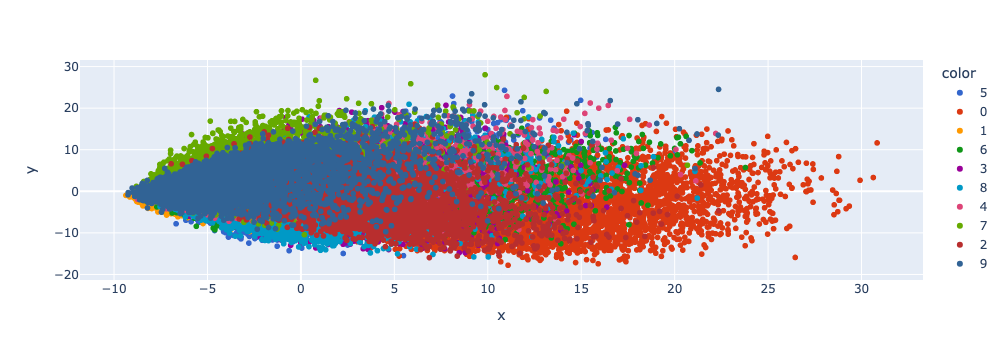

In [115]:
#plotting a 2D scatter plot using plotly
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [119]:
#transforming in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [120]:
X_train_trf

array([[ -0.04285026,  -1.92217345,  -2.50233661],
       [  8.15958855,  -4.4961712 ,  -4.74209866],
       [ -7.50488223,  -3.71910867,   5.1366242 ],
       ...,
       [ 10.27732442,  -9.28652151,  -1.82594462],
       [ 10.29728947, -12.41274533,   3.29437629],
       [ -2.87743198,  -0.81213933,  -1.447647  ]], shape=(48000, 3))

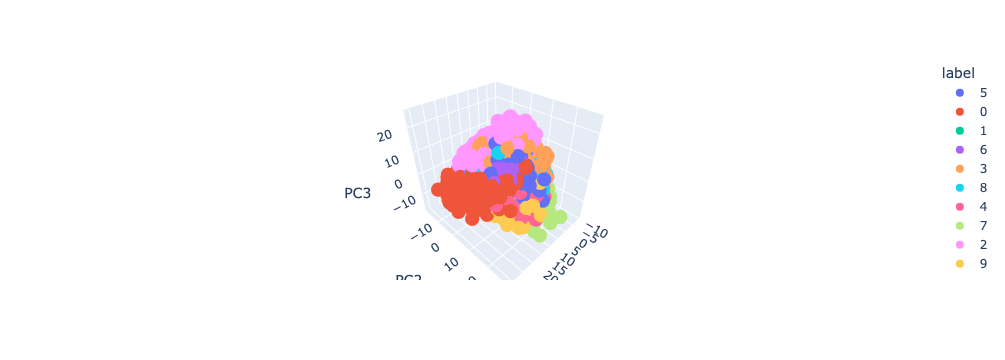

In [121]:
plot_df = pd.DataFrame({
    'PC1': X_train_trf[:,0],
    'PC2': X_train_trf[:,1],
    'PC3': X_train_trf[:,2],
    'label': y_train.astype(str)
})

fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='label'
)

fig.show()

In [122]:
#eigen values
pca.explained_variance_

array([40.65780534, 29.35286734, 26.72542354])

In [123]:
#eigen vectors
pca.components_.shape

(3, 784)

#No. of components required to reach variance sum of 90%

In [124]:
#eigen values percentage
pca.explained_variance_ratio_

array([0.05702238, 0.04116726, 0.03748228])

In [125]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [126]:
pca.explained_variance_.shape

(784,)

In [127]:
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(784, 784))

In [129]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05702238, 0.09818964, 0.13567192, 0.16469803, 0.18997512,
       0.21201816, 0.23145483, 0.24899896, 0.26449107, 0.27857721,
       0.29203612, 0.30418912, 0.31541422, 0.32643714, 0.33677905,
       0.34679973, 0.35628657, 0.36553212, 0.37450139, 0.3832566 ,
       0.39165487, 0.39977906, 0.40746453, 0.41493226, 0.42213525,
       0.42907204, 0.43594926, 0.44259091, 0.44892842, 0.45509787,
       0.46114434, 0.46706145, 0.47279214, 0.47848895, 0.48409704,
       0.48949156, 0.4948431 , 0.50008162, 0.50521951, 0.51006006,
       0.51486238, 0.51961237, 0.52422734, 0.52876164, 0.5332432 ,
       0.53769768, 0.54208869, 0.54644584, 0.55075226, 0.55491002,
       0.55903357, 0.56310875, 0.56711141, 0.57106149, 0.57495932,
       0.57881571, 0.58255742, 0.58627309, 0.58991977, 0.59351945,
       0.59709068, 0.60059041, 0.60404334, 0.60748518, 0.61090121,
       0.61426725, 0.61761329, 0.62090554, 0.62413045, 0.62730982,
       0.63046295, 0.63359184, 0.63668903, 0.6397278 , 0.64275

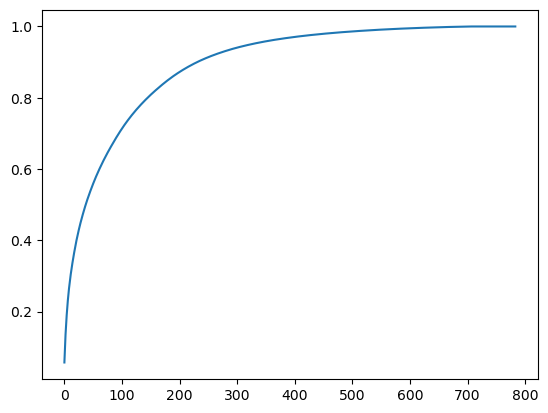

In [132]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

we can easily identify from this graph,at what no. of components variance ratio=90%